# DSO 560 NLP Project

# Dataset Cleaning and Description

The analysis uses the Steam Games Reviews and Rankings dataset, publicly available on Kaggle:

**Data Source:** [Steam Games Reviews and Rankings on Kaggle](https://www.kaggle.com/datasets/mohamedtarek01234/steam-games-reviews-and-rankings/data)

The dataset consists of three CSV files:

1.  **`games_description.csv`** (290 games metadata)
    *   `name`: The name of the game.
    *   `short_description`: A brief summary of the game.
    *   `long_description`: A detailed description of the game.
    *   `genres`: A comma-separated string of genres the game belongs to.
    *   `minimum_system_requirement`: Minimum hardware and software specifications needed to run the game.
    *   `recommend_system_requirement`: Recommended hardware and software specifications for optimal performance.
    *   `release_date`: The official release date of the game.
    *   `developer`: The developer(s) of the game.
    *   `publisher`: The publisher(s) of the game.
    *   `overall_player_rating`: The aggregate player rating (e.g., 'Overwhelmingly Positive', 'Very Positive').
    *   `number_of_reviews_from_purchased_people`: The count of reviews from users who purchased the game.
    *   `number_of_english_reviews`: The count of reviews written in English.
    *   `link`: A URL to the game's store page.
    *   *Derived Variables after Cleaning:*
        *   `release_date_parsed`: Datetime object of the release date.
        *   `genre_list`: A list of genres extracted from the `genres` string.
        *   `n_genres`: The number of genres associated with the game.

2.  **`games_ranking.csv`** (672 rows, game x genre x rank)
    *   `game_name`: The name of the game.
    *   `genre`: The genre category for which the game is ranked.
    *   `rank_type`: The type of ranking (e.g., 'Sales', 'Popularity').
    *   `rank`: The numerical rank of the game within its `genre` and `rank_type`.

3.  **`steam_game_reviews.csv`** (approximately 992,000 reviews, ~475 MB)
    *   `game_name`: The name of the game being reviewed.
    *   `username`: The username of the reviewer.
    *   `date`: The date when the review was posted.
    *   `hours_played`: The total hours the reviewer has played the game.
    *   `products_in_account`: The total number of products (games) in the reviewer's Steam account.
    *   `helpful`: The number of users who found the review helpful.
    *   `funny`: The number of users who found the review funny.
    *   `recommendation`: The reviewer's overall sentiment towards the game ('Recommended' or 'Not Recommended').
    *   `review`: The actual text content of the review.
    *   *Derived Variables after Cleaning:*
        *   `username_clean`: Cleaned username (PII-equivalent column dropped in final cleaned data).
        *   `products_in_account`: Number of products in the reviewer's account.
        *   `review_day`: Day of the month the review was posted.
        *   `review_month`: Month the review was posted.
        *   `review_year`: Year the review was posted.
        *   `is_recommended`: Binary flag (1 if recommended, 0 otherwise).
        *   `review_char_len`: Length of the review text in characters.
        *   `review_word_len`: Length of the review text in words.
        *   `is_hours_outlier`: Flag for outliers in hours played.
        *   `is_len_outlier`: Flag for outliers in review character length.
        *   `is_helpful_outlier`: Flag for outliers in helpful votes.
        *   `is_products_outlier`: Flag for outliers in products in account.

## Imports Data

In [ ]:
%matplotlib inline
from __future__ import annotations

import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS

drive.mount("/content/drive")

# Paths — raw data lives in Drive; outputs also go to Drive so they persist
DRIVE = Path("/content/drive/MyDrive")
RAW = DRIVE / "data"
assert RAW.exists(), f"RAW not found: {RAW}"

BASE = DRIVE / "cleaned_data_and_eda"
CLEAN = BASE / "cleaned_data"
TABLES = BASE / "eda_tables"
PLOTS = BASE / "eda_plots"

for p in (CLEAN, TABLES, PLOTS):
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 100, "savefig.bbox": "tight", "font.size": 10})

print("RAW  :", RAW)
print("BASE :", BASE)
print("Files in RAW:", [f.name for f in RAW.iterdir()])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RAW  : /content/drive/MyDrive/data
BASE : /content/drive/MyDrive/cleaned_data_and_eda
Files in RAW: ['games_description.csv', 'games_ranking.csv', 'steam_game_reviews.csv', 'cleaned_data', 'data_cleaning_and_eda.ipynb']


## Data Cleaning

In [ ]:
_WS = re.compile(r"\s+")
_MOJIBAKE = re.compile(r"[\ufffd\u2028\u2029]+")

def clean_text(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = _MOJIBAKE.sub(" ", s)
    s = _WS.sub(" ", s).strip()
    return s if s else np.nan

def to_int(x):
    """Parse '1,152' or 13 into an int; NA on failure."""
    if pd.isna(x):
        return pd.NA
    try:
        return int(str(x).replace(",", "").strip())
    except (ValueError, TypeError):
        return pd.NA

def parse_date_no_year(s):
    """Steam mixes two formats:
      - 'DD Month[, YYYY]'  e.g. '14 September' / '14 September, 2023'
      - 'Month DD[, YYYY]'  e.g. 'September 19' / 'December 15, 2017'
    Returns (day, month, year_or_NA).
    """
    if pd.isna(s):
        return (pd.NA, pd.NA, pd.NA)
    s = str(s).strip()
    m = re.match(r"(\d{1,2})\s+([A-Za-z]+),\s*(\d{4})$", s)
    if m:
        return (int(m.group(1)), m.group(2), int(m.group(3)))
    m = re.match(r"(\d{1,2})\s+([A-Za-z]+)$", s)
    if m:
        return (int(m.group(1)), m.group(2), pd.NA)
    m = re.match(r"([A-Za-z]+)\s+(\d{1,2}),\s*(\d{4})$", s)
    if m:
        return (int(m.group(2)), m.group(1), int(m.group(3)))
    m = re.match(r"([A-Za-z]+)\s+(\d{1,2})$", s)
    if m:
        return (int(m.group(2)), m.group(1), pd.NA)
    return (pd.NA, pd.NA, pd.NA)

def split_username(s):
    """'Sentinowl\\n224 products in account' -> ('Sentinowl', 224)."""
    if pd.isna(s):
        return (pd.NA, pd.NA)
    parts = str(s).split("\n")
    uname = parts[0].strip()
    prods = pd.NA
    if len(parts) > 1:
        m = re.search(r"(\d[\d,]*)\s+products", parts[1])
        if m:
            try:
                prods = int(m.group(1).replace(",", ""))
            except ValueError:
                prods = pd.NA
    return (uname if uname else pd.NA, prods)

This cell defines several helper functions crucial for data cleaning:
-   **`clean_text(x)`**: This function removes garbled characters (mojibake) and normalizes whitespace in text strings. It returns `np.nan` if the input is already `NaN` or if the cleaned string is empty, ensuring consistency.
-   **`to_int(x)`**: Designed to convert various inputs into integers. It handles strings that might contain commas (e.g., '1,152' becomes 1152) and gracefully returns `pd.NA` for non-convertible values or `NaN` inputs.
-   **`parse_date_no_year(s)`**: This function is specialized for parsing date strings from the Steam dataset, which often lack a year or follow different day-month/month-day formats. It attempts to extract the day, month, and year (if present), returning `pd.NA` for missing components.
-   **`split_username(s)`**: Extracts the username and the number of products in the reviewer's account from a single string that combines both pieces of information, such as 'Sentinowl\n224 products in account'.

### Clean `games_description.csv`

In [ ]:
gd = pd.read_csv(RAW / "games_description.csv")

str_cols = [
    "name", "short_description", "long_description", "genres",
    "minimum_system_requirement", "recommend_system_requirement",
    "release_date", "developer", "publisher", "overall_player_rating", "link",
]
for c in str_cols:
    if c in gd.columns:
        gd[c] = gd[c].map(clean_text)

for c in ["number_of_reviews_from_purchased_people", "number_of_english_reviews"]:
    gd[c] = gd[c].map(to_int).astype("Int64")

gd["release_date_parsed"] = pd.to_datetime(gd["release_date"], errors="coerce")
gd["genre_list"] = gd["genres"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)
gd["n_genres"] = gd["genre_list"].apply(len)
gd = gd.drop_duplicates(subset=["name"]).dropna(subset=["name"]).reset_index(drop=True)

gd.to_csv(CLEAN / "games_description_clean.csv", index=False)
print(f"games_description: {gd.shape}")
gd.head(3)

games_description: (290, 16)


,name,short_description,long_description,genres,minimum_system_requirement,recommend_system_requirement,release_date,developer,publisher,overall_player_rating,number_of_reviews_from_purchased_people,number_of_english_reviews,link,release_date_parsed,genre_list,n_genres
0,Black Myth: Wukong,Black Myth: Wukong is an action RPG rooted in ...,About This Game Black Myth: Wukong is an actio...,"['Mythology', 'Action RPG', 'Action', 'RPG', '...",['Requires a 64-bit processor and operating sy...,['Requires a 64-bit processor and operating sy...,"19 Aug, 2024",['Game Science'],['Game Science'],Overwhelmingly Positive,<NA>,51931,https://store.steampowered.com/app/2358720/Bla...,2024-08-19,"[['Mythology', 'Action RPG', 'Action', 'RPG', ...",20
1,Counter-Strike 2,"For over two decades, Counter-Strike has offer...","About This Game For over two decades, Counter-...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","['OS: Windows® 10', 'Processor: 4 hardware CPU...","['OS: Windows® 10', 'Processor: 4 hardware CPU...","21 Aug, 2012",['Valve'],['Valve'],Very Positive,<NA>,2258990,https://store.steampowered.com/app/730/Counter...,2012-08-21,"[['FPS', 'Shooter', 'Multiplayer', 'Competitiv...",20
2,"Warhammer 40,000: Space Marine 2",Embody the superhuman skill and brutality of a...,About This Game Embody the superhuman skill an...,"['Warhammer 40K', 'Action', 'Third-Person Shoo...",['Requires a 64-bit processor and operating sy...,['Requires a 64-bit processor and operating sy...,"9 Sep, 2024",['Saber Interactive'],['Focus Entertainment'],Very Positive,<NA>,51920,https://store.steampowered.com/app/2183900/War...,2024-09-09,"[['Warhammer 40K', 'Action', 'Third-Person Sho...",20


### Clean `games_ranking.csv`

In [ ]:
gr = pd.read_csv(RAW / "games_ranking.csv")
for c in ["game_name", "genre", "rank_type"]:
    gr[c] = gr[c].map(clean_text)
gr["rank"] = gr["rank"].map(to_int).astype("Int64")
gr = gr.drop_duplicates().dropna(subset=["game_name", "genre", "rank_type"]).reset_index(drop=True)

gr.to_csv(CLEAN / "games_ranking_clean.csv", index=False)
print(f"games_ranking: {gr.shape}")
gr.head(3)

games_ranking: (672, 4)


,game_name,genre,rank_type,rank
0,Counter-Strike 2,Action,Sales,1
1,"Warhammer 40,000: Space Marine 2",Action,Sales,2
2,Cyberpunk 2077,Action,Sales,3


### Clean `steam_game_reviews.csv` (chunked)

The file is ~475 MB / ~992k rows, so it's streamed in 100k-row chunks and appended to disk.

In [ ]:
CHUNK = 100_000
out_path = CLEAN / "steam_game_reviews_clean.csv"
if out_path.exists():
    out_path.unlink()

reader = pd.read_csv(RAW / "steam_game_reviews.csv", chunksize=CHUNK, low_memory=False)
total_in = total_out = 0
first = True

for i, df in enumerate(reader, 1):
    total_in += len(df)

    df["review"] = df["review"].map(clean_text)
    df["game_name"] = df["game_name"].map(clean_text)
    df["recommendation"] = df["recommendation"].map(clean_text)

    df["hours_played"] = pd.to_numeric(df["hours_played"], errors="coerce")
    df["helpful"] = df["helpful"].map(to_int).astype("Int64")
    df["funny"] = df["funny"].map(to_int).astype("Int64")

    uparts = df["username"].map(split_username)
    df["username_clean"] = uparts.map(lambda t: t[0])
    df["products_in_account"] = uparts.map(lambda t: t[1]).astype("Int64")

    dparts = df["date"].map(parse_date_no_year)
    df["review_day"] = dparts.map(lambda t: t[0]).astype("Int64")
    df["review_month"] = dparts.map(lambda t: t[1])
    df["review_year"] = dparts.map(lambda t: t[2]).astype("Int64")

    df["is_recommended"] = (df["recommendation"] == "Recommended").astype("Int64")
    df["review_char_len"] = df["review"].fillna("").str.len().astype("Int64")
    df["review_word_len"] = df["review"].fillna("").str.split().map(len).astype("Int64")

    df = df.dropna(subset=["review"])
    df = df.drop_duplicates(subset=["username_clean", "game_name", "review"])

    keep = [
        "game_name", "username_clean", "products_in_account",
        "recommendation", "is_recommended",
        "hours_played", "helpful", "funny",
        "review_day", "review_month", "review_year",
        "review_char_len", "review_word_len", "review",
    ]
    df = df[keep]
    df.to_csv(out_path, mode="a", index=False, header=first, encoding="utf-8")
    first = False
    total_out += len(df)
    if i % 2 == 0 or i == 1:
        print(f"  chunk {i}: in={total_in:,} out={total_out:,}")

print(f"\nDONE. input rows: {total_in:,}  -> clean rows: {total_out:,}")
print(f"Dropped {total_in - total_out:,} rows (empty/duplicate reviews).")

  chunk 1: in=100,000 out=99,965
  chunk 2: in=200,000 out=199,948
  chunk 4: in=400,000 out=399,890
  chunk 6: in=600,000 out=599,790
  chunk 8: in=800,000 out=799,680
  chunk 10: in=992,153 out=991,647

DONE. input rows: 992,153  -> clean rows: 991,647
Dropped 506 rows (empty/duplicate reviews).


## Aggressive cleaning (null fills + outlier flags)

This section handled **structural** issues (types, duplicates, text encoding). This section handles **remaining nulls and outliers**:

- `helpful`, `funny`, `products_in_account` → fill NaN with 0 (no votes = 0)
- `developer`, `publisher`, `overall_player_rating` → fill with "Unknown" / "No user reviews"
- Drop reviews with <3 words (too short to be useful for text analysis)
- Flag (don't drop) 99th-percentile outliers for `hours_played`, `review_char_len`, `helpful`, `products_in_account` via `is_*_outlier` boolean columns

The outlier thresholds are computed on the full corpus and saved to `outlier_thresholds.csv` for reproducibility.

In [ ]:
def _run_full_cleaning():
    print(">>> *_final.csv not found — running full cleaning pipeline in-place ...")

    _WS = re.compile(r"\s+") # Regex for whitespace
    _MOJIBAKE = re.compile(r"[\ufffd\u2028\u2029]+") # Regex for mojibake characters

    def _clean_text(x):
        """Removes mojibake, normalizes whitespace, and strips strings."""
        if pd.isna(x): return np.nan
        s = _WS.sub(" ", _MOJIBAKE.sub(" ", str(x))).strip()
        return s if s else np.nan

    def _to_int(x):
        """Safely converts string to int, handling commas and errors."""
        if pd.isna(x): return pd.NA
        try: return int(str(x).replace(",", "").strip())
        except (ValueError, TypeError): return pd.NA

    def _parse_date(s):
        """Parses inconsistent date formats into (day, month, year)."""
        if pd.isna(s): return (pd.NA, pd.NA, pd.NA)
        s = str(s).strip()
        for pat, order in [
            (r"(\d{1,2})\s+([A-Za-z]+),\s*(\d{4})$", "dmy"),
            (r"(\d{1,2})\s+([A-Za-z]+)$", "dm"),
            (r"([A-Za-z]+)\s+(\d{1,2}),\s*(\d{4})$", "mdy"),
            (r"([A-Za-z]+)\s+(\d{1,2})$", "md"),
        ]:
            m = re.match(pat, s)
            if m:
                if order == "dmy": return (int(m.group(1)), m.group(2), int(m.group(3)))
                if order == "dm":  return (int(m.group(1)), m.group(2), pd.NA)
                if order == "mdy": return (int(m.group(2)), m.group(1), int(m.group(3)))
                if order == "md":  return (int(m.group(2)), m.group(1), pd.NA)
        return (pd.NA, pd.NA, pd.NA)

    def _split_username(s):
        """Extracts username and product count from combined string."""
        if pd.isna(s): return (pd.NA, pd.NA)
        parts = str(s).split("\n")
        uname = parts[0].strip()
        prods = pd.NA
        if len(parts) > 1:
            m = re.search(r"(\d[\d,]*)\s+products", parts[1])
            if m:
                try: prods = int(m.group(1).replace(",", ""))
                except ValueError: prods = pd.NA
        return (uname if uname else pd.NA, prods)

    # --- Cleaning for 'games_description.csv' ---
    gd_ = pd.read_csv(RAW / "games_description.csv")
    for c in ["name", "genres", "release_date", "developer", "publisher",
              "overall_player_rating", "short_description", "long_description",
              "minimum_system_requirement", "recommend_system_requirement", "link"]:
        if c in gd_.columns:
            gd_[c] = gd_[c].map(_clean_text)
    for c in ["number_of_reviews_from_purchased_people", "number_of_english_reviews"]:
        gd_[c] = gd_[c].map(_to_int).astype("Int64")
    gd_ = gd_.drop_duplicates(subset=["name"]).dropna(subset=["name"]).reset_index(drop=True)
    gd_["overall_player_rating"] = gd_["overall_player_rating"].fillna("No user reviews")
    gd_["number_of_reviews_from_purchased_people"] = gd_["number_of_reviews_from_purchased_people"].fillna(0).astype("Int64")
    gd_["number_of_english_reviews"] = gd_["number_of_english_reviews"].fillna(0).astype("Int64")
    gd_ = gd_[[
        "name", "genres", "release_date", "overall_player_rating",
        "number_of_reviews_from_purchased_people", "number_of_english_reviews",
    ]]
    gd_.to_csv(CLEAN / "games_description_final.csv", index=False)
    print(f"  games_description_final: {gd_.shape}")

    # --- Cleaning for 'games_ranking.csv' ---
    gr_ = pd.read_csv(RAW / "games_ranking.csv")
    for c in ["game_name", "genre", "rank_type"]:
        gr_[c] = gr_[c].map(_clean_text)
    gr_["rank"] = gr_["rank"].map(_to_int).astype("Int64")
    gr_ = gr_.drop_duplicates().dropna(subset=["game_name", "genre", "rank_type"]).reset_index(drop=True)
    gr_.to_csv(CLEAN / "games_ranking_final.csv", index=False)
    print(f"  games_ranking_final:     {gr_.shape}")

    # --- Cleaning for 'steam_game_reviews.csv': Pass 1 (structural cleaning to temporary file) ---
    tmp = CLEAN / "_reviews_tmp.csv"
    if tmp.exists(): tmp.unlink()
    first, total_in, total_out = True, 0, 0
    for df in pd.read_csv(RAW / "steam_game_reviews.csv", chunksize=200_000, low_memory=False):
        total_in += len(df)
        df["review"] = df["review"].map(_clean_text)
        df["game_name"] = df["game_name"].map(_clean_text)
        df["recommendation"] = df["recommendation"].map(_clean_text)
        df["hours_played"] = pd.to_numeric(df["hours_played"], errors="coerce")
        df["helpful"] = df["helpful"].map(_to_int).astype("Int64")
        df["funny"] = df["funny"].map(_to_int).astype("Int64")
        up = df["username"].map(_split_username)
        df["username_clean"] = up.map(lambda t: t[0])
        df["products_in_account"] = up.map(lambda t: t[1]).astype("Int64")
        dp = df["date"].map(_parse_date)
        df["review_day"] = dp.map(lambda t: t[0]).astype("Int64")
        df["review_month"] = dp.map(lambda t: t[1])
        df["review_year"] = dp.map(lambda t: t[2]).astype("Int64")
        df["is_recommended"] = (df["recommendation"] == "Recommended").astype("Int64")
        df["review_char_len"] = df["review"].fillna("").str.len().astype("Int64")
        df["review_word_len"] = df["review"].fillna("").str.split().map(len).astype("Int64")
        df = df.dropna(subset=["review"]).drop_duplicates(subset=["username_clean", "game_name", "review"])
        df = df[["game_name", "username_clean", "products_in_account",
                 "recommendation", "is_recommended", "hours_played", "helpful", "funny",
                 "review_day", "review_month", "review_year",
                 "review_char_len", "review_word_len", "review"]]
        df.to_csv(tmp, mode="a", index=False, header=first, encoding="utf-8")
        first = False
        total_out += len(df)
    print(f"  reviews pass 1: {total_in:,} -> {total_out:,}")

    # --- Cleaning for 'steam_game_reviews.csv': Pass 2a (compute 99-percentile thresholds for outliers) ---
    H, C, HP, PR = [], [], [], []
    for ch in pd.read_csv(tmp, usecols=["hours_played", "review_char_len", "helpful", "products_in_account"], chunksize=200_000):
        H.append(ch["hours_played"].dropna().values)
        C.append(ch["review_char_len"].dropna().values)
        HP.append(ch["helpful"].dropna().values)
        PR.append(ch["products_in_account"].dropna().values)
    qh = float(np.quantile(np.concatenate(H), 0.99))
    qc = float(np.quantile(np.concatenate(C), 0.99))
    qhp = float(np.quantile(np.concatenate(HP), 0.99))
    qpr = float(np.quantile(np.concatenate(PR), 0.99))
    del H, C, HP, PR
    pd.Series({"hours_played_q99": qh, "review_char_len_q99": qc,
               "helpful_q99": qhp, "products_in_account_q99": qpr,
               "min_review_words": 3}).to_csv(CLEAN / "outlier_thresholds.csv", header=["value"])
    print(f"  thresholds: hours={qh:.1f}, chars={qc:.0f}, helpful={qhp:.0f}, products={qpr:.0f}")

    # --- Cleaning for 'steam_game_reviews.csv': Pass 2b (final fills, flags, drops, and output) ---
    dst = CLEAN / "steam_game_reviews_final.csv"
    if dst.exists(): dst.unlink()
    first, dropped, rows_out = True, 0, 0
    for ch in pd.read_csv(tmp, chunksize=200_000, low_memory=False):
        m = ch["review_word_len"] < 3
        dropped += int(m.sum())
        ch = ch.loc[~m].copy()
        ch["helpful"] = ch["helpful"].fillna(0).astype("Int64")
        ch["funny"] = ch["funny"].fillna(0).astype("Int64")
        ch["products_in_account"] = ch["products_in_account"].fillna(0).astype("Int64")
        ch["is_hours_outlier"]    = (ch["hours_played"] > qh).fillna(False).astype("int8")
        ch["is_len_outlier"]      = (ch["review_char_len"] > qc).fillna(False).astype("int8")
        ch["is_helpful_outlier"]  = (ch["helpful"] > qhp).fillna(False).astype("int8")
        ch["is_products_outlier"] = (ch["products_in_account"] > qpr).fillna(False).astype("int8")
        ch = ch.drop(columns=["username_clean"])  # team spec: drop PII-equivalent column
        ch.to_csv(dst, mode="a", index=False, header=first, encoding="utf-8")
        first = False
        rows_out += len(ch)
    tmp.unlink()
    print(f"  reviews pass 2: dropped {dropped:,} short (<3 words) -> final: {rows_out:,}")
    print(">>> Cleaning complete.\n")


# --- Automatic Cleaning Trigger ---
required = ["games_description_final.csv", "games_ranking_final.csv", "steam_game_reviews_final.csv"]
if not all((CLEAN / f).exists() for f in required):
    _run_full_cleaning()

# ----- Load cleaned data for EDA (Exploratory Data Analysis) -----
gd = pd.read_csv(CLEAN / "games_description_final.csv")
gr = pd.read_csv(CLEAN / "games_ranking_final.csv")

rev_cols_light = [
    "game_name", "products_in_account",
    "recommendation", "is_recommended",
    "hours_played", "helpful", "funny",
    "review_day", "review_month", "review_year",
    "review_char_len", "review_word_len",
    "is_hours_outlier", "is_len_outlier", "is_helpful_outlier", "is_products_outlier",
]
rev = pd.read_csv(CLEAN / "steam_game_reviews_final.csv", usecols=rev_cols_light)
print("games_description:", gd.shape)
print("games_ranking   :", gr.shape)
print("reviews (light)  :", rev.shape)
print("\nNulls in reviews (expect only hours_played + review_year):")
print(rev.isna().sum()[rev.isna().sum() > 0].to_string())

# --- Helper function for saving figures ---
def savefig(name):
    """Saves figure to PLOTS dir and displays it inline."""
    plt.savefig(PLOTS / name)
    plt.show()

games_description: (290, 16)
games_ranking   : (672, 4)
reviews (light)  : (383228, 16)

Nulls in reviews (expect only hours_played + review_year):
hours_played    33236
review_year     75457


In [ ]:
# --- 4b.3 steam_game_reviews: compute outlier thresholds (pass 1) ---
src = CLEAN / "steam_game_reviews_clean.csv"

print("Pass 1/2: computing 99th-percentile thresholds on full corpus ...")
hours_samples, char_samples, help_samples, prod_samples = [], [], [], []
for chunk in pd.read_csv(
    src,
    usecols=["hours_played", "review_char_len", "helpful", "products_in_account"],
    chunksize=200_000,
):
    hours_samples.append(chunk["hours_played"].dropna().values)
    char_samples.append(chunk["review_char_len"].dropna().values)
    help_samples.append(chunk["helpful"].dropna().values)
    prod_samples.append(chunk["products_in_account"].dropna().values)

hours_q99 = float(np.quantile(np.concatenate(hours_samples), 0.99))
chars_q99 = float(np.quantile(np.concatenate(char_samples), 0.99))
help_q99 = float(np.quantile(np.concatenate(help_samples), 0.99))
prod_q99 = float(np.quantile(np.concatenate(prod_samples), 0.99))
del hours_samples, char_samples, help_samples, prod_samples

print(f"  hours_played 99th pct       = {hours_q99:,.1f}")
print(f"  review_char_len 99th pct    = {chars_q99:,.0f}")
print(f"  helpful 99th pct            = {help_q99:,.0f}")
print(f"  products_in_account 99th    = {prod_q99:,.0f}")

pd.Series({
    "hours_played_q99": hours_q99,
    "review_char_len_q99": chars_q99,
    "helpful_q99": help_q99,
    "products_in_account_q99": prod_q99,
    "min_review_words": 3,
}).to_csv(CLEAN / "outlier_thresholds.csv", header=["value"])
print("Saved -> outlier_thresholds.csv")

Pass 1/2: computing 99th-percentile thresholds on full corpus ...
  hours_played 99th pct       = 875.8
  review_char_len 99th pct    = 4,277
  helpful 99th pct            = 403
  products_in_account 99th    = 3,257
Saved -> outlier_thresholds.csv


In [ ]:
summary = {
    "n_games_described": int(gd.shape[0]),
    "n_ranked_games": int(gr["game_name"].nunique()),
    "n_reviews": int(rev.shape[0]),
    "n_games_in_reviews": int(rev["game_name"].nunique()),
    "pct_recommended": float(rev["is_recommended"].mean() * 100),
    "avg_review_char_len": float(rev["review_char_len"].mean()),
    "median_review_char_len": float(rev["review_char_len"].median()),
    "avg_review_word_len": float(rev["review_word_len"].mean()),
    "median_review_word_len": float(rev["review_word_len"].median()),
    "avg_hours_played": float(rev["hours_played"].mean()),
    "median_hours_played": float(rev["hours_played"].median()),
}
pd.Series(summary).to_csv(TABLES / "01_overall_summary.csv", header=["value"])
pd.Series(summary)

,0
n_games_described,290.000000
n_ranked_games,303.000000
n_reviews,383228.000000
n_games_in_reviews,87.000000
pct_recommended,82.546161
avg_review_char_len,434.447869
median_review_char_len,124.000000
avg_review_word_len,77.017945
median_review_word_len,22.000000
avg_hours_played,126.549400


### Save final files to Drive



In [ ]:
# import shutil
# from pathlib import Path

# DRIVE_OUT = Path("/content/drive/MyDrive/cleaned_data")
# DRIVE_OUT.mkdir(parents=True, exist_ok=True)

# if Path(CLEAN).resolve() == DRIVE_OUT.resolve():
#     print(f"CLEAN already points to {DRIVE_OUT} — nothing to copy.")
# else:
#     print(f"Copying final files: {CLEAN}  ->  {DRIVE_OUT}")
#     for name in ["games_description_final.csv", "games_ranking_final.csv",
#                  "steam_game_reviews_final.csv", "outlier_thresholds.csv"]:
#         src = CLEAN / name
#         if src.exists():
#             shutil.copyfile(src, DRIVE_OUT / name)
#             print(f"  ✅ {name}  ({src.stat().st_size / 1e6:.1f} MB)")
#         else:
#             print(f"  ⚠️  {name} 不存在,跳过")
#     print(f"\n✅ Drive 中已保存到: {DRIVE_OUT}")

Copying final files: /content/drive/MyDrive/cleaned_data_and_eda/cleaned_data  ->  /content/drive/MyDrive/cleaned_data
  ✅ games_description_final.csv  (1.1 MB)
  ✅ games_ranking_final.csv  (0.0 MB)
  ✅ steam_game_reviews_final.csv  (204.2 MB)
  ✅ outlier_thresholds.csv  (0.0 MB)

✅ Drive 中已保存到: /content/drive/MyDrive/cleaned_data


### Load cleaned data for EDA



In [ ]:
gd = pd.read_csv(CLEAN / "games_description_clean.csv")
gr = pd.read_csv(CLEAN / "games_ranking_clean.csv")

rev_cols_light = [
    "game_name", "username_clean", "products_in_account",
    "recommendation", "is_recommended",
    "hours_played", "helpful", "funny",
    "review_day", "review_month", "review_year",
    "review_char_len", "review_word_len",
]
rev = pd.read_csv(CLEAN / "steam_game_reviews_clean.csv", usecols=rev_cols_light)
print("games_description:", gd.shape)
print("games_ranking   :", gr.shape)
print("reviews (light)  :", rev.shape)

def savefig(name):
    """Save figure to PLOTS dir AND display inline in the notebook."""
    plt.savefig(PLOTS / name)
    plt.show()

games_description: (290, 16)
games_ranking   : (672, 4)
reviews (light)  : (199948, 13)


## EDA

In [ ]:
summary = {
    "n_games_described": int(gd.shape[0]),
    "n_ranked_games": int(gr["game_name"].nunique()),
    "n_reviews": int(rev.shape[0]),
    "n_unique_users": int(rev["username_clean"].nunique()),
    "n_games_in_reviews": int(rev["game_name"].nunique()),
    "pct_recommended": float(rev["is_recommended"].mean() * 100),
    "avg_review_char_len": float(rev["review_char_len"].mean()),
    "median_review_char_len": float(rev["review_char_len"].median()),
    "avg_review_word_len": float(rev["review_word_len"].mean()),
    "median_review_word_len": float(rev["review_word_len"].median()),
    "avg_hours_played": float(rev["hours_played"].mean()),
    "median_hours_played": float(rev["hours_played"].median()),
}
pd.Series(summary).to_csv(TABLES / "01_overall_summary.csv", header=["value"])
pd.Series(summary)

,0
n_games_described,290.000000
n_ranked_games,303.000000
n_reviews,199948.000000
n_unique_users,163199.000000
n_games_in_reviews,43.000000
pct_recommended,76.756457
avg_review_char_len,437.707369
median_review_char_len,110.000000
avg_review_word_len,77.070473
median_review_word_len,19.000000


### Recommendation distribution

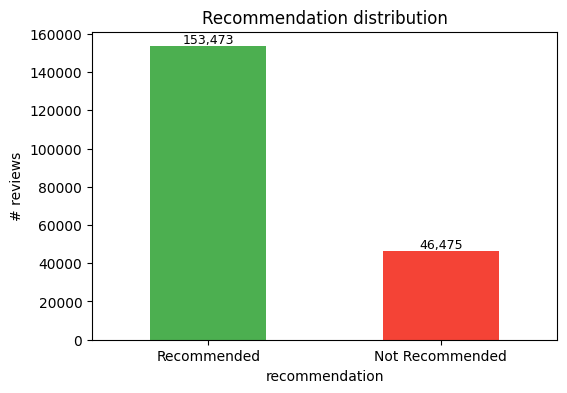

,count
recommendation,
Recommended,153473
Not Recommended,46475


In [ ]:
rec_counts = rev["recommendation"].value_counts(dropna=False)
rec_counts.to_csv(TABLES / "02_recommendation_counts.csv", header=["count"])

plt.figure(figsize=(6, 4))
rec_counts.plot.bar(color=["#4caf50", "#f44336"][: len(rec_counts)])
plt.title("Recommendation distribution")
plt.ylabel("# reviews")
plt.xticks(rotation=0)
for i, v in enumerate(rec_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
savefig("02_recommendation_distribution.png")
rec_counts

### Review length by sentiment

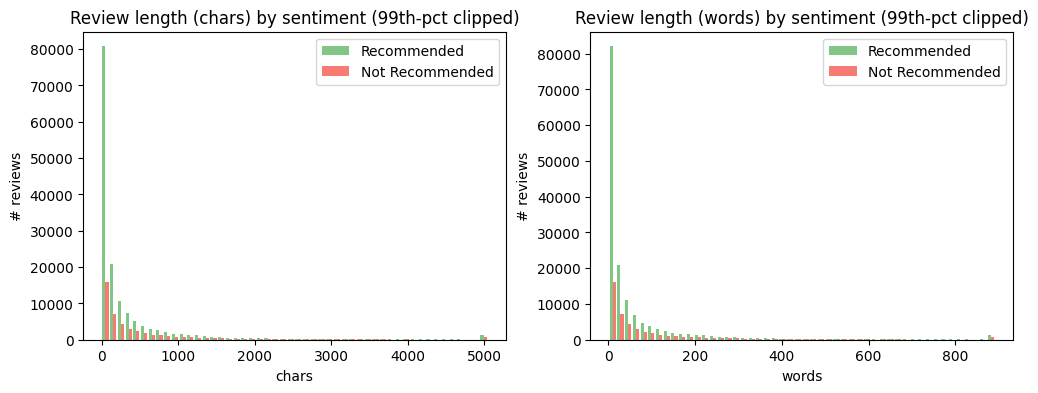

review_char_len                                             \
                          count        mean          std  min   25%    50%   
recommendation                                                               
Not Recommended         46475.0  600.683400  1074.389390  1.0  66.0  206.0   
Recommended            153473.0  388.354642   861.761607  1.0  34.0   91.0   

                               review_word_len                               \
                   75%     max           count        mean         std  min   
recommendation                                                                
Not Recommended  621.0  8271.0         46475.0  107.174653  190.717131  1.0   
Recommended      334.0  8155.0        153473.0   67.954266  151.333725  1.0   

                                            
                  25%   50%    75%     max  
recommendation                              
Not Recommended  12.0  37.0  112.0  1557.0  
Recommended       6.0  16.0   57.0  2666.0

In [ ]:
length_stats = rev.groupby("recommendation")[["review_char_len", "review_word_len"]].describe()
length_stats.to_csv(TABLES / "03_review_length_by_sentiment.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, col, ax in [("chars", "review_char_len", axes[0]), ("words", "review_word_len", axes[1])]:
    clip = rev[col].clip(upper=rev[col].quantile(0.99))
    ax.hist(
        [clip[rev["is_recommended"] == 1], clip[rev["is_recommended"] == 0]],
        bins=50, label=["Recommended", "Not Recommended"],
        color=["#4caf50", "#f44336"], alpha=0.7,
    )
    ax.set_title(f"Review length ({label}) by sentiment (99th-pct clipped)")
    ax.set_xlabel(label)
    ax.set_ylabel("# reviews")
    ax.legend()
savefig("03_review_length_distribution.png")
length_stats

### Hours played distribution

<Figure size 800x600 with 0 Axes>

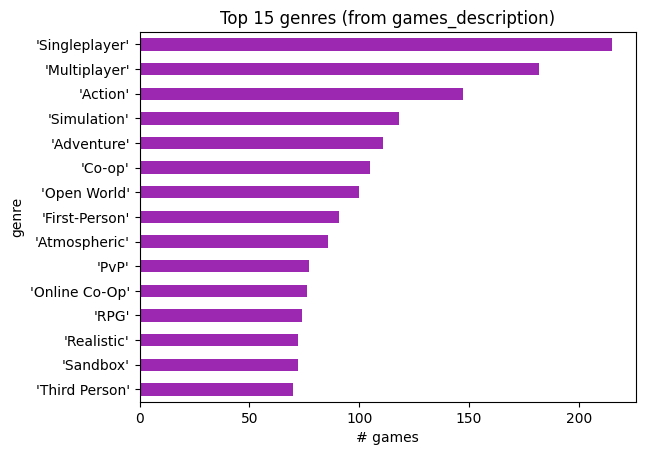

,genre,n_games
0,'Singleplayer',215
1,'Multiplayer',182
2,'Action',147
3,'Simulation',118
4,'Adventure',111
5,'Co-op',105
6,'Open World',100
7,'First-Person',91
8,'Atmospheric',86
9,'PvP',77


In [ ]:
# Derive genre list on the fly from the comma-separated `genres` column
all_genres = Counter()
for s in gd["genres"].fillna(""):
    for g in str(s).split(","):
        g = g.strip()
        if g:
            all_genres[g] += 1
genre_df = pd.DataFrame(all_genres.most_common(), columns=["genre", "n_games"])
genre_df.to_csv(TABLES / "06_genre_counts_from_description.csv", index=False)

plt.figure(figsize=(8, 6))
genre_df.head(15)[::-1].plot.barh(x="genre", y="n_games", legend=False, color="#9c27b0")
plt.title("Top 15 genres (from games_description)")
plt.xlabel("# games")
savefig("06_top_genres.png")

rank_genres = gr["genre"].value_counts()
rank_genres.to_csv(TABLES / "06b_ranking_genres.csv", header=["n_entries"])
genre_df.head(10)

### Top games & best/worst by % recommended

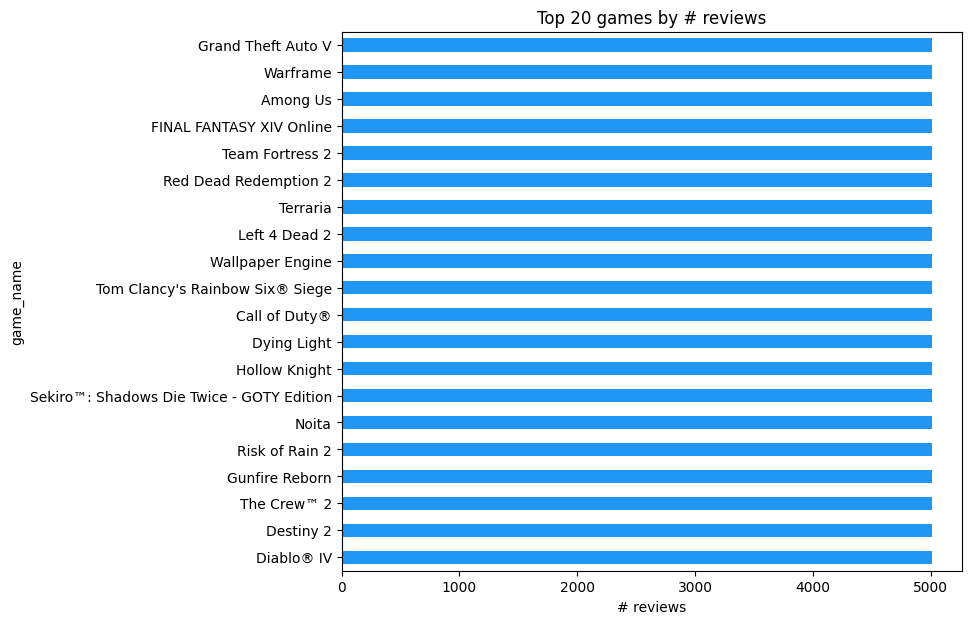

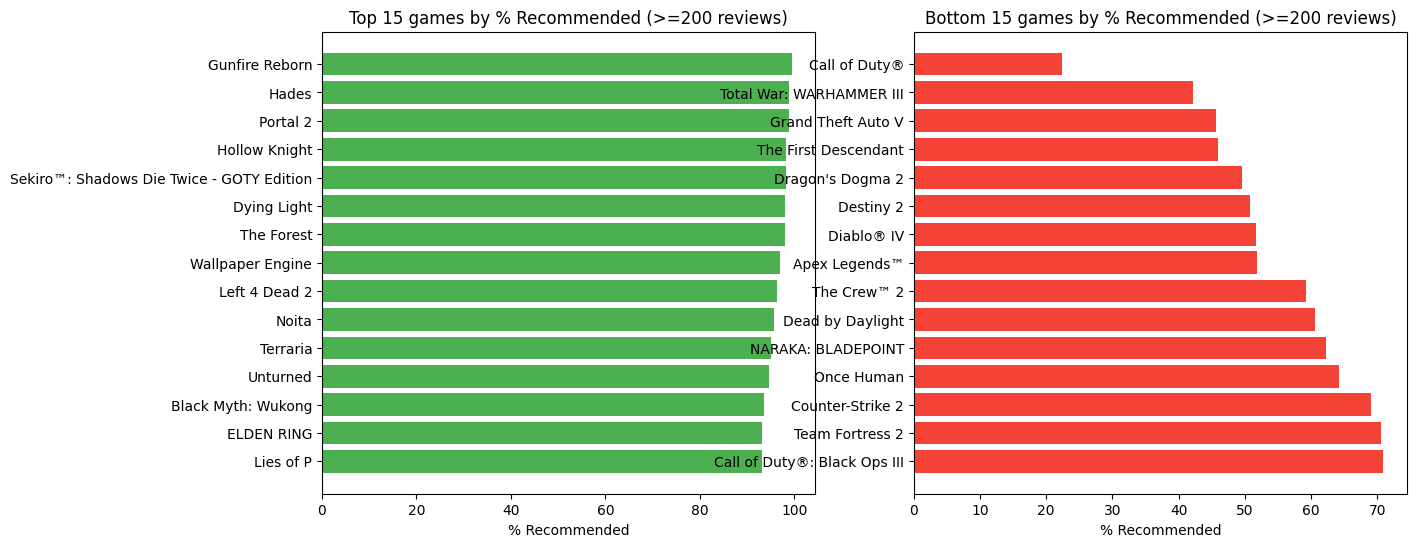

,count
game_name,
Grand Theft Auto V,5010
Warframe,5010
Among Us,5010
FINAL FANTASY XIV Online,5010
Team Fortress 2,5010
Red Dead Redemption 2,5010
Terraria,5010
Left 4 Dead 2,5010
Wallpaper Engine,5010


In [ ]:
top20 = rev["game_name"].value_counts().head(20)
top20.to_csv(TABLES / "05_top20_games_by_reviews.csv", header=["review_count"])

plt.figure(figsize=(8, 7))
top20[::-1].plot.barh(color="#2196f3")
plt.title("Top 20 games by # reviews")
plt.xlabel("# reviews")
savefig("05_top20_games_by_reviews.png")

per_game = rev.groupby("game_name").agg(
    n_reviews=("is_recommended", "size"),
    pct_recommended=("is_recommended", "mean"),
    avg_hours=("hours_played", "mean"),
).reset_index()
per_game["pct_recommended"] *= 100
per_game = per_game.sort_values("n_reviews", ascending=False)
per_game.to_csv(TABLES / "05b_per_game_stats.csv", index=False)

eligible = per_game[per_game["n_reviews"] >= 200].copy()
best = eligible.sort_values("pct_recommended", ascending=False).head(15)
worst = eligible.sort_values("pct_recommended", ascending=True).head(15)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(best["game_name"][::-1], best["pct_recommended"][::-1], color="#4caf50")
axes[0].set_title("Top 15 games by % Recommended (>=200 reviews)")
axes[0].set_xlabel("% Recommended")
axes[1].barh(worst["game_name"][::-1], worst["pct_recommended"][::-1], color="#f44336")
axes[1].set_title("Bottom 15 games by % Recommended (>=200 reviews)")
axes[1].set_xlabel("% Recommended")
savefig("05c_best_worst_games.png")
top20

### Genres

<Figure size 800x600 with 0 Axes>

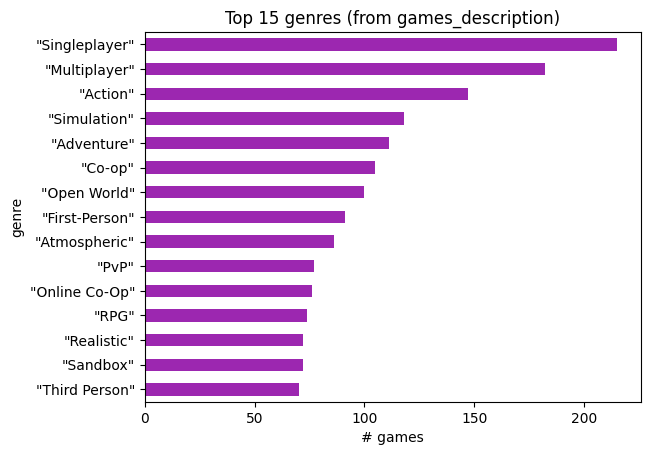

,genre,n_games
0,"""Singleplayer""",215
1,"""Multiplayer""",182
2,"""Action""",147
3,"""Simulation""",118
4,"""Adventure""",111
5,"""Co-op""",105
6,"""Open World""",100
7,"""First-Person""",91
8,"""Atmospheric""",86
9,"""PvP""",77


In [ ]:
gd_genres = (
    gd["genre_list"].fillna("[]")
    .str.strip("[]").str.replace("'", "").str.split(", ")
)
all_genres = Counter()
for lst in gd_genres:
    for g in lst:
        g = g.strip()
        if g:
            all_genres[g] += 1
genre_df = pd.DataFrame(all_genres.most_common(), columns=["genre", "n_games"])
genre_df.to_csv(TABLES / "06_genre_counts_from_description.csv", index=False)

plt.figure(figsize=(8, 6))
genre_df.head(15)[::-1].plot.barh(x="genre", y="n_games", legend=False, color="#9c27b0")
plt.title("Top 15 genres (from games_description)")
plt.xlabel("# games")
savefig("06_top_genres.png")

rank_genres = gr["genre"].value_counts()
rank_genres.to_csv(TABLES / "06b_ranking_genres.csv", header=["n_entries"])
genre_df.head(10)

### Zipf's law

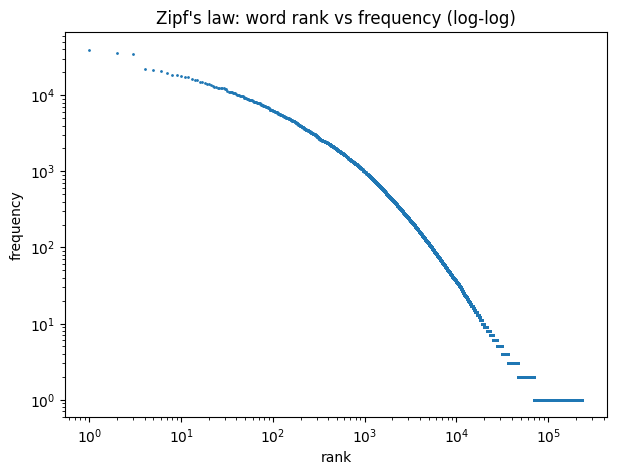

total unique tokens: 235942


In [ ]:
all_counts = Counter()
for s in text_df["review"].astype(str):
    for tok in s.lower().split():
        tok = "".join(c for c in tok if c.isalpha())
        if tok and tok not in STOP and len(tok) > 1:
            all_counts[tok] += 1

freqs = np.array(sorted(all_counts.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)
plt.figure(figsize=(7, 5))
plt.loglog(ranks, freqs, marker=".", linestyle="none", markersize=2)
plt.title("Zipf's law: word rank vs frequency (log-log)")
plt.xlabel("rank")
plt.ylabel("frequency")
savefig("10_zipf_law.png")
print("total unique tokens:", len(all_counts))

### Descriptive Analysis for presentation

In [ ]:
total_reviews = len(merged_df)
unique_games = merged_df['game_name'].nunique()

print(f'CORPUS SUMMARY')
print(f'-----------------')
print(f'Total Reviews (Documents): {total_reviews:,}')
print(f'Total Unique Games: {unique_games}')

In [ ]:
# Define month mapping
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Create a clean DataFrame for date conversion
date_df = pd.DataFrame({
    'year': merged_df['review_year'].fillna(2024),
    'month': merged_df['review_month'].map(month_map),
    'day': merged_df['review_day']
})

# Convert to datetime
temp_dates = pd.to_datetime(date_df, errors='coerce')

earliest_review = temp_dates.min()
latest_review = temp_dates.max()

print(f'TIME SPAN OF DATA')
print(f'-----------------')
print(f'Earliest Review: {earliest_review.strftime("%B %d, %Y") if not pd.isnull(earliest_review) else "Unknown"}')
print(f'Latest Review:   {latest_review.strftime("%B %d, %Y") if not pd.isnull(latest_review) else "Unknown"}')

In [ ]:
# Descriptive statistics for review word length
stats = merged_df['review_word_len'].describe()
median_len = merged_df['review_word_len'].median()
std_len = merged_df['review_word_len'].std()

# Calculate percentage of very short reviews (< 10 words)
short_reviews_threshold = 10
short_reviews_count = (merged_df['review_word_len'] < short_reviews_threshold).sum()
short_reviews_pct = (short_reviews_count / len(merged_df)) * 100

print(f'REVIEW LENGTH STATISTICS (WORDS)')
print(f'--------------------------------')
print(f'Mean Length:    {stats["mean"]:,.2f}')
print(f'Median Length:  {median_len:,.2f}')
print(f'Std Deviation:  {std_len:,.2f}')
print(f'Min Length:     {stats["min"]:,.0f}')
print(f'Max Length:     {stats["max"]:,.0f}')
print(f'\nSHORT REVIEW ANALYSIS')
print(f'--------------------------------')
print(f'Reviews < {short_reviews_threshold} words: {short_reviews_count:,}')
print(f'Percentage: {short_reviews_pct:.2f}%')

In [ ]:
# Aggregate genres for each game into a single string
game_genres = ranking.groupby('game_name')['genre'].apply(lambda x: ', '.join(x.unique())).reset_index()
game_genres.rename(columns={'genre': 'genres'}, inplace=True)

# Merge this genre information with the docs_per_game_only DataFrame
docs_per_game_with_all_genres = docs_per_game_only.merge(game_genres, on='game_name', how='left')

print(f"Total unique games with genre information: {len(docs_per_game_with_all_genres)}")
display(docs_per_game_with_all_genres.head(10))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = ranking['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

plt.figure(figsize=(10, 5))
sns.barplot(x='genre', y='count', data=genre_counts, color='purple', width=0.6) # Reduced bar width
plt.title('Distribution of Game Genres', fontsize=16) # Larger title
plt.xlabel('Genre', fontsize=14) # Larger x-axis label
plt.ylabel('Number of Games', fontsize=14) # Larger y-axis label
plt.xticks(fontsize=12) # Larger x-tick labels
plt.yticks(fontsize=12) # Larger y-tick labels
plt.tight_layout()
plt.show()

# Basic Text Analysis

**Tasks:**
1. Basic text processing — tokenization + stopword removal
2. Word frequency comparison — positive vs negative reviews
3. N-grams (bigrams + trigrams) — especially for negative reviews
4. Basic TF-IDF — discriminative keywords


## imports, Drive mount, paths

In [ ]:
%matplotlib inline
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Try to mount Drive (Colab); otherwise stay local
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Path to the cleaned reviews file. Edit if your Drive layout differs.
CANDIDATE_PATHS = [
    Path("/content/drive/MyDrive/cleaned_data/steam_game_reviews_final.csv"),
    Path("/content/drive/MyDrive/cleaned data/steam_game_reviews_final.csv"),
    Path("/content/drive/MyDrive/cleaned dataset/steam_game_reviews_final.csv"),
    Path.cwd() / "cleaned dataset" / "steam_game_reviews_final.csv",
    Path.cwd() / "steam_game_reviews_final.csv",
]
REVIEWS_CSV = next((p for p in CANDIDATE_PATHS if p.exists()), None)
assert REVIEWS_CSV, f"Cleaned reviews CSV not found. Tried: {CANDIDATE_PATHS}"
print("Using:", REVIEWS_CSV)

# Output folder for tables and figures
OUT = REVIEWS_CSV.parent.parent / "group3_outputs"
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)
print("Outputs ->", OUT)

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 10})

Mounted at /content/drive
Using: /content/drive/MyDrive/cleaned_data/steam_game_reviews_final.csv
Outputs -> /content/drive/MyDrive/group3_outputs


### Load reviews (sampled for speed)

The full corpus has ~920k reviews. For word frequency / n-gram / TF-IDF, sampling 150k reviews is more than enough for stable rankings (and runs in <1 min). Bump `SAMPLE_SIZE` to `None` to use the full file.

In [ ]:
SAMPLE_SIZE = 150_000  # set to None to use the full corpus

rev = pd.read_csv(REVIEWS_CSV, usecols=["review", "is_recommended"])
print("Total reviews:", f"{len(rev):,}")
rev = rev.dropna(subset=["review", "is_recommended"])
rev["is_recommended"] = rev["is_recommended"].astype(int)

if SAMPLE_SIZE and len(rev) > SAMPLE_SIZE:
    rev = rev.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print("Sample size  :", f"{len(rev):,}")

pos_texts = rev.loc[rev["is_recommended"] == 1, "review"].astype(str)
neg_texts = rev.loc[rev["is_recommended"] == 0, "review"].astype(str)
print(f"  positive: {len(pos_texts):,}")
print(f"  negative: {len(neg_texts):,}")
rev.head(3)

Total reviews: 383,228
Sample size  : 150,000
  positive: 123,888
  negative: 26,112


,is_recommended,review
0,0,2023 No video game is good enough for you to d...
1,1,2014 if you found Portal 1 short then portal 2...
2,1,2023 More games like this and less like Forces...


## Basic text processing — tokenization + stopwords

Steps:
1. Lowercase
2. Tokenize — keep only alphabetic tokens of length ≥ 2 via regex `\b[a-zA-Z][a-zA-Z]+\b`
3. Remove stopwords — sklearn's English list + a custom `GAME_STOPS` list of game-specific filler words (game, play, steam, …) that would otherwise dominate every chart

Implementation note: instead of looping over rows by hand, we hand the regex `token_pattern` and the `stop_words` list to sklearn's `CountVectorizer` / `TfidfVectorizer`. Same result, way faster on 150k reviews.

In [ ]:
# sklearn's built-in English stopword list (ENGLISH_STOP_WORDS) is solid;
# we extend it with words that are noise for this domain.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

GAME_STOPS = {
    "game", "games", "play", "plays", "playing", "played", "player", "players",
    "steam", "review", "reviews", "time", "really", "like",
    "just", "one", "much", "still", "even", "also", "way", "thing", "things",
    "get", "got", "make", "made", "well", "good",  # 'good' / 'great' / 'fun' too generic in pos
    "im", "its", "ive", "dont", "thats", "didnt", "doesnt", "isnt",
}
STOPWORDS = set(ENGLISH_STOP_WORDS) | GAME_STOPS

TOKEN_PATTERN = r"(?u)\b[a-zA-Z][a-zA-Z]+\b"

def show_pipeline(s):
    """Walk through tokenization on one review for the slides / sanity check."""
    raw = s
    lower = s.lower()
    toks = re.findall(TOKEN_PATTERN, lower)
    no_stop = [t for t in toks if t not in STOPWORDS]
    return raw, lower, toks, no_stop

sample_review = pos_texts.iloc[0]
raw, lower, toks, no_stop = show_pipeline(sample_review)
print("RAW (first 200 chars):\n ", raw[:200], "...\n")
print("LOWERCASED:\n ", lower[:200], "...\n")
print("TOKENS (first 25):\n ", toks[:25], "\n")
print("AFTER STOPWORD REMOVAL (first 25):\n ", no_stop[:25])
print("\nVocab size after filtering:", len(set(no_stop)))

RAW (first 200 chars):
  2014 if you found Portal 1 short then portal 2 is your cure there are more puzzels a better story super multi player co-op Graphics 10/ 10 sound and effects 10 / 10 story 9 /10 difficulty curve 8 /10  ...

LOWERCASED:
  2014 if you found portal 1 short then portal 2 is your cure there are more puzzels a better story super multi player co-op graphics 10/ 10 sound and effects 10 / 10 story 9 /10 difficulty curve 8 /10  ...

TOKENS (first 25):
  ['if', 'you', 'found', 'portal', 'short', 'then', 'portal', 'is', 'your', 'cure', 'there', 'are', 'more', 'puzzels', 'better', 'story', 'super', 'multi', 'player', 'co', 'op', 'graphics', 'sound', 'and', 'effects'] 

AFTER STOPWORD REMOVAL (first 25):
  ['portal', 'short', 'portal', 'cure', 'puzzels', 'better', 'story', 'super', 'multi', 'op', 'graphics', 'sound', 'effects', 'story', 'difficulty', 'curve', 'gameplay']

Vocab size after filtering: 15


## Word frequency — positive vs negative (top 20)

In [ ]:
def top_terms(texts, n=20, ngram=(1, 1), min_df=5):
    """Return a DataFrame of the top n terms (by count) for the given texts."""
    vec = CountVectorizer(
        stop_words=list(STOPWORDS),
        token_pattern=TOKEN_PATTERN,
        ngram_range=ngram,
        min_df=min_df,
        max_features=20_000,
    )
    X = vec.fit_transform(texts)
    freq = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = freq.argsort()[::-1][:n]
    return pd.DataFrame({"term": vocab[order], "count": freq[order]})

pos_top = top_terms(pos_texts, n=20)
neg_top = top_terms(neg_texts, n=20)
pos_top.to_csv(OUT / "tables" / "top20_words_positive.csv", index=False)
neg_top.to_csv(OUT / "tables" / "top20_words_negative.csv", index=False)

print("=== TOP 20 — POSITIVE ===")
print(pos_top.to_string(index=False))
print("\n=== TOP 20 — NEGATIVE ===")
print(neg_top.to_string(index=False))

=== TOP 20 — POSITIVE ===
     term  count
      fun  30846
    early  24848
   access  23900
    story  22268
    great  22085
     best  17803
      don  16793
      new  15797
    hours  15359
       ve  14930
     love  14516
 gameplay  13869
    world  13326
  friends  12747
      lot  12707
  amazing  11460
recommend  11062
   better  11012
     want  10643
   people  10609

=== TOP 20 — NEGATIVE ===
     term  count
      don   7427
      fun   6263
      new   5885
   people   5194
    hours   5051
     want   4682
       ve   4392
    money   4336
     free   4110
      buy   4071
      bad   3898
    story   3601
   better   3513
  content   3494
    early   3430
   access   3297
    great   3172
recommend   3128
      lot   3085
     feel   2961


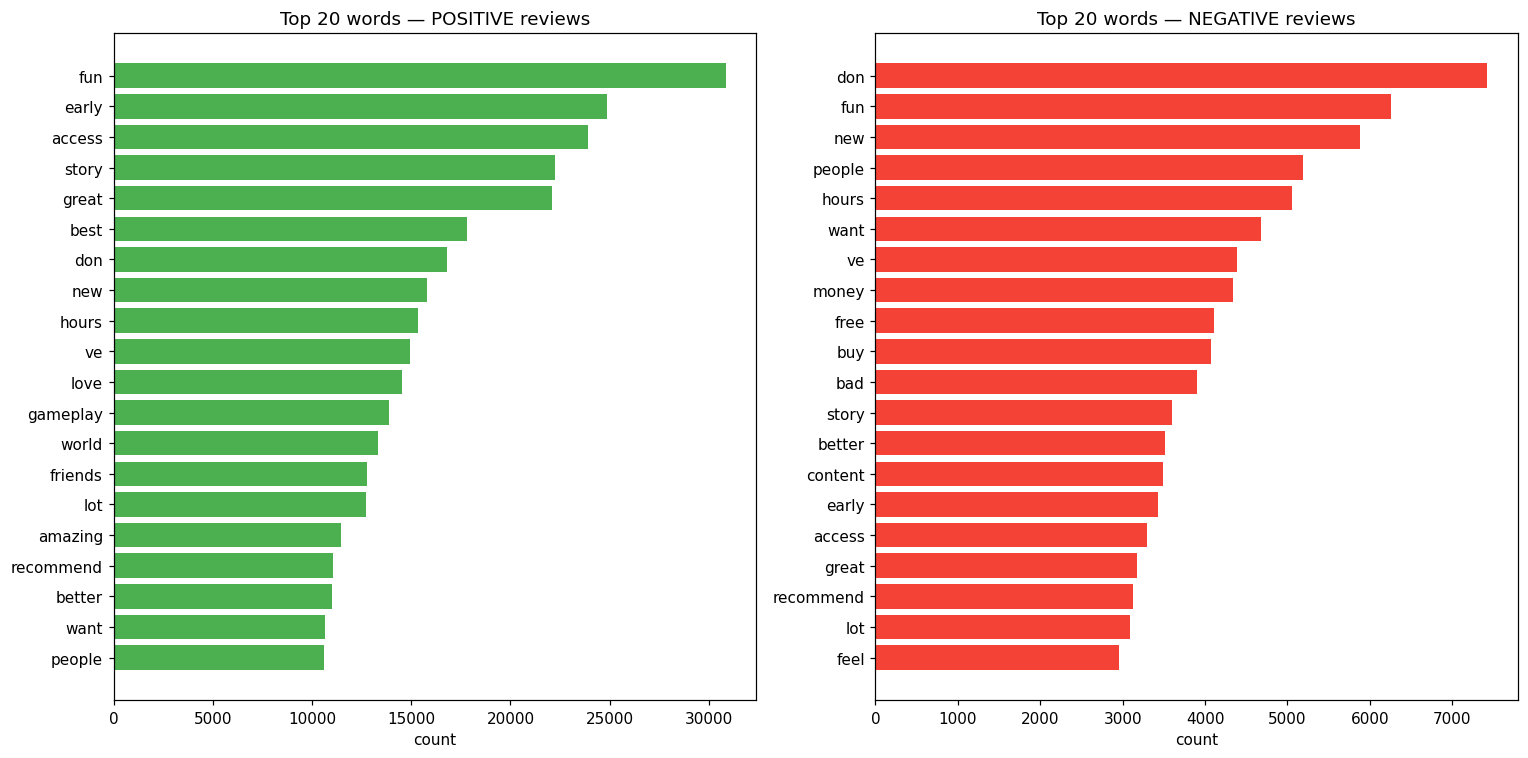

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(pos_top["term"][::-1], pos_top["count"][::-1], color="#4caf50")
axes[0].set_title("Top 20 words — POSITIVE reviews")
axes[0].set_xlabel("count")
axes[1].barh(neg_top["term"][::-1], neg_top["count"][::-1], color="#f44336")
axes[1].set_title("Top 20 words — NEGATIVE reviews")
axes[1].set_xlabel("count")
plt.tight_layout()
plt.savefig(OUT / "plots" / "top20_words_pos_vs_neg.png")
plt.show()

## N-grams — bigrams and trigrams

Single words are blunt. Bigrams capture phrases like *"early access"*, *"pay to win"*, *"open world"* — much more interpretable for slides.

In [ ]:
pos_bi = top_terms(pos_texts, n=20, ngram=(2, 2), min_df=10)
neg_bi = top_terms(neg_texts, n=20, ngram=(2, 2), min_df=10)
pos_bi.to_csv(OUT / "tables" / "top20_bigrams_positive.csv", index=False)
neg_bi.to_csv(OUT / "tables" / "top20_bigrams_negative.csv", index=False)

print("=== TOP 20 BIGRAMS — POSITIVE ===")
print(pos_bi.to_string(index=False))
print("\n=== TOP 20 BIGRAMS — NEGATIVE ===")
print(neg_bi.to_string(index=False))

=== TOP 20 BIGRAMS — POSITIVE ===
            term  count
    early access  23237
       meow meow   4340
   received free   4303
product received   4287
      dark souls   3561
      open world   2765
highly recommend   2274
         boy boy   2115
     grind grind   2026
     fun friends   1793
      rock stone   1579
     worth price   1472
        don know   1240
         buy buy   1219
         lot fun   1213
       rich rich   1209
      access fun   1172
       art style   1129
   hollow knight   1128
    voice acting   1081

=== TOP 20 BIGRAMS — NEGATIVE ===
              term  count
      early access   2878
       crash crash   1868
     received free    724
  product received    722
        open world    596
          don know    528
     current state    468
           don buy    468
  product refunded    456
           ve seen    424
         total war    420
          don want    403
          don care    371
        anti cheat    349
   ubisoft connect    346
        gta

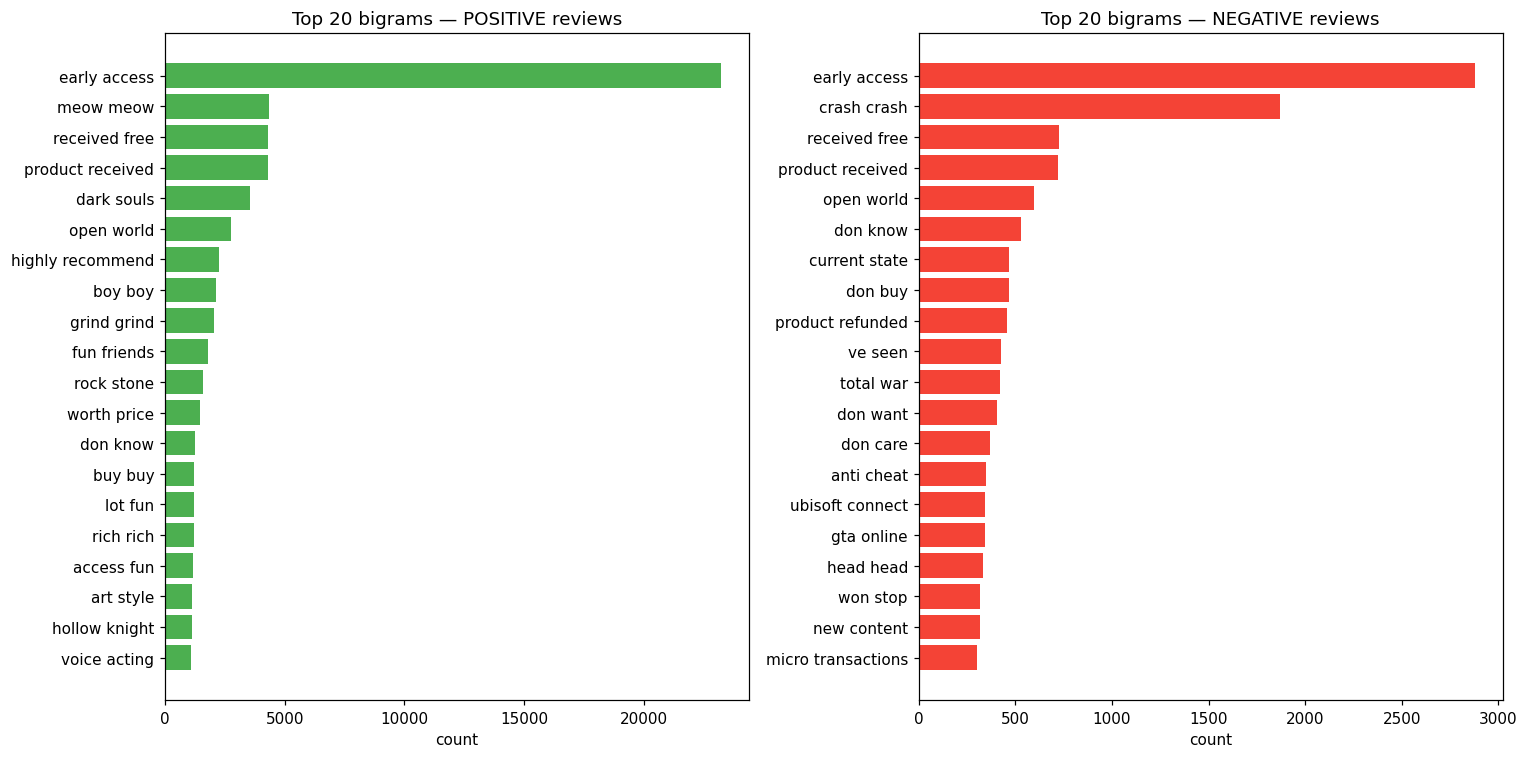

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(pos_bi["term"][::-1], pos_bi["count"][::-1], color="#4caf50")
axes[0].set_title("Top 20 bigrams — POSITIVE reviews")
axes[0].set_xlabel("count")
axes[1].barh(neg_bi["term"][::-1], neg_bi["count"][::-1], color="#f44336")
axes[1].set_title("Top 20 bigrams — NEGATIVE reviews")
axes[1].set_xlabel("count")
plt.tight_layout()
plt.savefig(OUT / "plots" / "top20_bigrams_pos_vs_neg.png")
plt.show()

In [ ]:
# Trigrams — focus on negative since they show concrete complaints
neg_tri = top_terms(neg_texts, n=15, ngram=(3, 3), min_df=10)
neg_tri.to_csv(OUT / "tables" / "top15_trigrams_negative.csv", index=False)
print("=== TOP 15 TRIGRAMS — NEGATIVE ===")
print(neg_tri.to_string(index=False))

=== TOP 15 TRIGRAMS — NEGATIVE ===
                         term  count
            crash crash crash   1838
        product received free    722
         ark survival evolved    164
      recommend current state    114
        refunded early access    109
       product refunded early    109
          total war warhammer    107
              don waste money     89
   privilege entitlement earn     70
      right discuss privilege     69
discuss privilege entitlement     61
             early access ark     57
             grand theft auto     54
          received free early     43
        ark survival ascended     43


## TF-IDF — most discriminative words (positive vs negative)

Raw counts tell you *frequent* words, but not which words **distinguish** positive from negative. TF-IDF + a per-class average gives words that are both frequent **and** specific to one class.

In [ ]:
tfidf = TfidfVectorizer(
    stop_words=list(STOPWORDS),
    token_pattern=TOKEN_PATTERN,
    ngram_range=(1, 1),
    min_df=10,
    max_features=15_000,
)
X = tfidf.fit_transform(rev["review"].astype(str))
vocab = np.array(tfidf.get_feature_names_out())
labels = rev["is_recommended"].values

pos_mean = np.asarray(X[labels == 1].mean(axis=0)).ravel()
neg_mean = np.asarray(X[labels == 0].mean(axis=0)).ravel()
diff = pos_mean - neg_mean

pos_disc = (
    pd.DataFrame({"term": vocab, "score": diff})
    .sort_values("score", ascending=False)
    .head(20).reset_index(drop=True)
)
neg_disc = (
    pd.DataFrame({"term": vocab, "score": -diff})
    .sort_values("score", ascending=False)
    .head(20).reset_index(drop=True)
)
pos_disc.to_csv(OUT / "tables" / "tfidf_top20_positive.csv", index=False)
neg_disc.to_csv(OUT / "tables" / "tfidf_top20_negative.csv", index=False)

print("=== TF-IDF — most POSITIVE-distinctive ===")
print(pos_disc.to_string(index=False))
print("\n=== TF-IDF — most NEGATIVE-distinctive ===")
print(neg_disc.to_string(index=False))

=== TF-IDF — most POSITIVE-distinctive ===
       term    score
      early 0.024945
     access 0.024795
       best 0.021358
        fun 0.019230
      great 0.014852
    amazing 0.011610
       love 0.011247
    friends 0.010052
       nice 0.006900
      story 0.006875
    awesome 0.006515
  beautiful 0.004584
   received 0.004157
     highly 0.004063
      souls 0.003984
   survival 0.003826
masterpiece 0.003820
        yes 0.003704
 definitely 0.003699
    perfect 0.003647

=== TF-IDF — most NEGATIVE-distinctive ===
       term    score
        fix 0.011761
      money 0.010533
    servers 0.009868
    crashes 0.009819
        bad 0.008906
        don 0.008785
     update 0.008272
         ea 0.008036
 unplayable 0.008003
        dlc 0.007998
     server 0.007266
     boring 0.006651
      worse 0.006505
   refunded 0.006439
     online 0.006209
      worst 0.005927
   terrible 0.005879
   rockstar 0.005740
performance 0.005635
     issues 0.005625


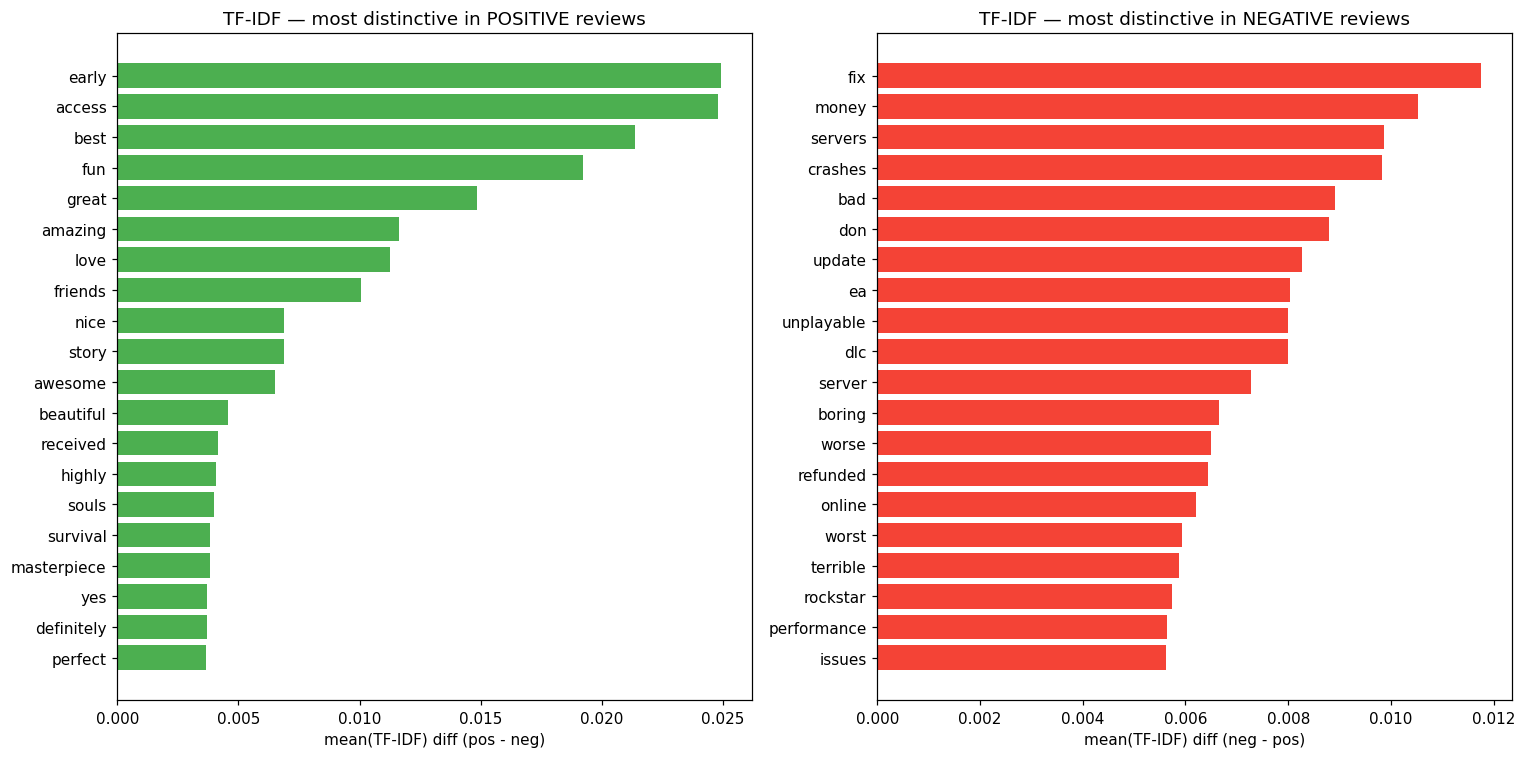

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(pos_disc["term"][::-1], pos_disc["score"][::-1], color="#4caf50")
axes[0].set_title("TF-IDF — most distinctive in POSITIVE reviews")
axes[0].set_xlabel("mean(TF-IDF) diff (pos - neg)")
axes[1].barh(neg_disc["term"][::-1], neg_disc["score"][::-1], color="#f44336")
axes[1].set_title("TF-IDF — most distinctive in NEGATIVE reviews")
axes[1].set_xlabel("mean(TF-IDF) diff (neg - pos)")
plt.tight_layout()
plt.savefig(OUT / "plots" / "tfidf_pos_vs_neg.png")
plt.show()

## Word clouds (one for each class)

pos-distinctive vocab: 4,185 words
neg-distinctive vocab: 3,815 words


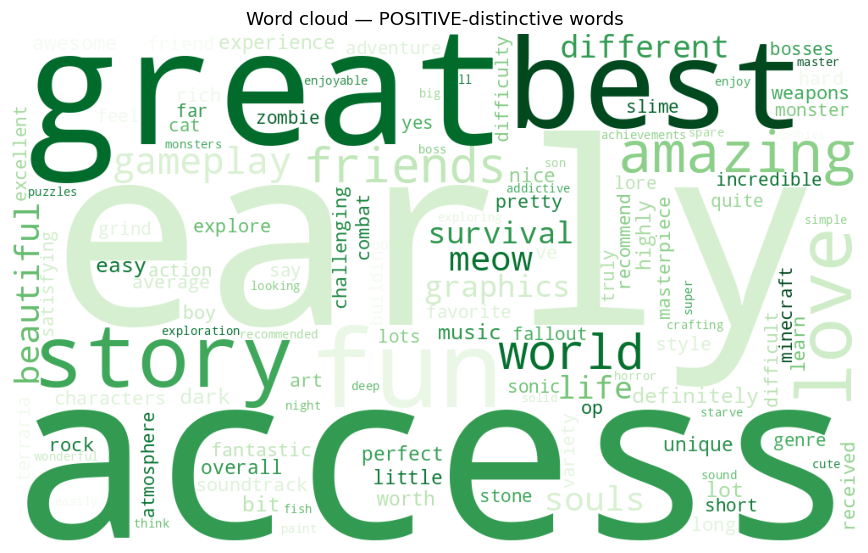

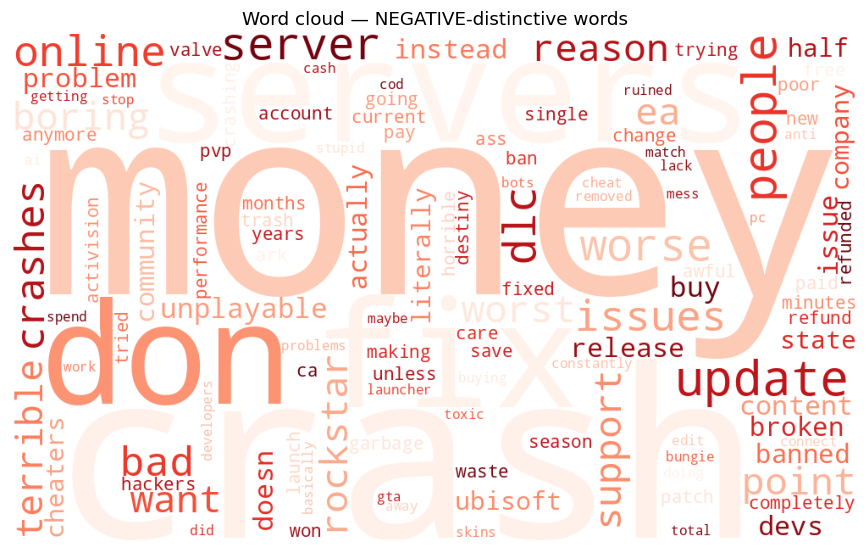

In [ ]:
  try:
      from wordcloud import WordCloud
  except ImportError:
      import sys, subprocess
      subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "wordcloud"])
      from wordcloud import WordCloud

  vec_cloud = CountVectorizer(
      stop_words=list(STOPWORDS),
      token_pattern=TOKEN_PATTERN,
      min_df=10, max_features=8000,
  )
  X_cloud = vec_cloud.fit_transform(rev["review"].astype(str))
  vocab_cloud = np.array(vec_cloud.get_feature_names_out())
  labels_cloud = rev["is_recommended"].values

  pos_counts = np.asarray(X_cloud[labels_cloud == 1].sum(axis=0)).ravel().astype(float)
  neg_counts = np.asarray(X_cloud[labels_cloud == 0].sum(axis=0)).ravel().astype(float)

  # 归一化(两个类的样本量不一样,直接比 raw count 不公平)
  pos_rate = pos_counts / max(pos_counts.sum(), 1)
  neg_rate = neg_counts / max(neg_counts.sum(), 1)

  pos_distinct = np.clip(pos_rate - neg_rate, 0, None)
  neg_distinct = np.clip(neg_rate - pos_rate, 0, None)

  pos_freq = {w: float(s) for w, s in zip(vocab_cloud, pos_distinct) if s > 0}
  neg_freq = {w: float(s) for w, s in zip(vocab_cloud, neg_distinct) if s > 0}
  print(f"pos-distinctive vocab: {len(pos_freq):,} words")
  print(f"neg-distinctive vocab: {len(neg_freq):,} words")

  def make_cloud_from_freq(freq_dict, title, path, colormap):
      wc = WordCloud(
          width=1000, height=600, background_color="white",
          collocations=False, colormap=colormap,
          max_words=120,
      ).generate_from_frequencies(freq_dict)
      plt.figure(figsize=(10, 6))
      plt.imshow(wc); plt.axis("off"); plt.title(title)
      plt.savefig(path, bbox_inches="tight", dpi=150)
      plt.show()

  make_cloud_from_freq(pos_freq, "Word cloud — POSITIVE-distinctive words",
                       OUT / "plots" / "wordcloud_positive.png", "Greens")
  make_cloud_from_freq(neg_freq, "Word cloud — NEGATIVE-distinctive words",
                       OUT / "plots" / "wordcloud_negative.png", "Reds")

## Summary — common complaints vs common praise

Compose a quick narrative for the slides by grouping the discriminative terms into themes.

In [ ]:
# Manually assign each top discriminative term to a theme. Adjust as you see fit.
neg_themes = {
    "Monetization / pricing": ["money", "dlc", "pay", "refund", "refunded",
                                "price", "micro", "transactions", "full"],
    "Technical issues":       ["bug", "bugs", "crash", "crashes", "crashing",
                                "broken", "unplayable", "fix", "lag", "servers"],
    "Bad gameplay / value":   ["boring", "trash", "worst", "worse", "bad",
                                "waste", "garbage", "awful"],
    "Early-access frustration": ["early", "access", "state", "beta", "unfinished"],
}
pos_themes = {
    "Fun / replay value":     ["fun", "amazing", "awesome", "love", "loved", "best"],
    "Story / world":          ["story", "characters", "world", "art", "music", "atmosphere"],
    "Multiplayer / co-op":    ["friends", "multiplayer", "coop", "online", "together"],
    "Polish / quality":       ["masterpiece", "beautiful", "perfect", "smooth", "polished"],
}

def theme_hits(disc_df, themes):
    rows = []
    seen = set()
    for theme, words in themes.items():
        hits = [(w, float(disc_df.loc[disc_df.term == w, "score"].iloc[0]))
                for w in words if w in disc_df.term.values and w not in seen]
        seen.update(w for w, _ in hits)
        if hits:
            rows.append((theme, ", ".join(f"{w} ({s:.4f})" for w, s in hits)))
    return pd.DataFrame(rows, columns=["theme", "top discriminative terms (score)"])

neg_summary = theme_hits(neg_disc, neg_themes)
pos_summary = theme_hits(pos_disc, pos_themes)
neg_summary.to_csv(OUT / "tables" / "summary_negative_themes.csv", index=False)
pos_summary.to_csv(OUT / "tables" / "summary_positive_themes.csv", index=False)

print("NEGATIVE THEMES (common complaints):")
print(neg_summary.to_string(index=False))
print("\nPOSITIVE THEMES (common praise):")
print(pos_summary.to_string(index=False))

NEGATIVE THEMES (common complaints):
                 theme                                      top discriminative terms (score)
Monetization / pricing                       money (0.0105), dlc (0.0080), refunded (0.0064)
      Technical issues crashes (0.0098), unplayable (0.0080), fix (0.0118), servers (0.0099)
  Bad gameplay / value         boring (0.0067), worst (0.0059), worse (0.0065), bad (0.0089)

POSITIVE THEMES (common praise):
              theme                                               top discriminative terms (score)
 Fun / replay value fun (0.0192), amazing (0.0116), awesome (0.0065), love (0.0112), best (0.0214)
      Story / world                                                                 story (0.0069)
Multiplayer / co-op                                                               friends (0.0101)
   Polish / quality                     masterpiece (0.0038), beautiful (0.0046), perfect (0.0036)
